# Mobility Economy Data Analysis with Python

## Project Context

This notebook examines the relationship between urban mobility conditions and economic performance across major Latin American cities.

Using traffic data from the TomTom Traffic Index and city-level economic indicators from OECD Cities, the workflow focuses on cleaning, standardizing, integrating, and analyzing both sources to produce a reliable 2024 analytical dataset for comparative interpretation.


## 1. Data Loading and Initial Review

The analysis begins by importing the required libraries and loading both source files into pandas DataFrames.

An initial inspection is used to understand the structure of each dataset, review available variables, and identify potential issues in column names, data types, and overall consistency before moving into preprocessing.


In [32]:
# importar librería
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
    # cargar archivos
    traffic = pd.read_csv("/datasets/tomtom_traffic.csv")
    eco = pd.read_csv("/datasets/oecd_city_economy.csv")


In [34]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [35]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Technical note:** tables are rendered more clearly when displayed directly rather than wrapped in multiple `print()` calls.


## 2. Data Inspection, Cleaning, and Preparation

Before merging the two sources, both datasets are reviewed for structural consistency, missing values, incompatible types, and naming issues.

This stage prepares the information for downstream analysis by standardizing fields, correcting formats, and documenting the main preprocessing decisions.


In [36]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


### Traffic Dataset Assessment

The traffic dataset should be reviewed primarily for:

- datetime fields that need conversion before period-based filtering,
- numeric traffic metrics that must remain in analyzable format,
- city and country identifiers that should be consistent for grouping and merging,
- missing values or anomalies that could affect aggregated city-level results.


In [37]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


### Economic Dataset Assessment

The economic dataset requires validation of both identifier fields and numeric indicators before integration.

Key checks include:

- ensuring `year` is available in numeric form for merging,
- reviewing `city` for naming consistency with the traffic dataset,
- validating economic indicators such as GDP per capita, unemployment, air quality, and population,
- identifying nulls or formatting issues caused by separators, symbols, or locale-specific notation.


### 2.1 Column Standardization

Column names are standardized to `snake_case` to improve readability, reduce syntax friction, and support a cleaner analytical workflow.

This is especially useful when merging sources and referencing variables repeatedly throughout the notebook.


In [39]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic = traffic.rename(columns={
    "Country": "country",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_kms",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_hist_per_10kms_mins",
    "MinsDelay": "mins_delay"
})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [40]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco = eco.rename(columns={
    "Year": "year",
    "City": "city",
    "Country": "country",
    "City GDP/capita": "city_gdp_capita",
    "Unemployment %": "unemployment_pct",
    "PM2.5 (μg/m³)": "pm25",
    "Population (M)": "population_m"
})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### 2.2 Type Correction for Dates and Numeric Fields

At this stage, date columns are converted to proper `datetime` format and selected economic variables are cleaned into numeric form.

This conversion is necessary to support reliable filtering, aggregation, and comparisons across cities in the final merged dataset.


**Processing note:** when numeric fields contain symbols or locale-specific separators, they should be cleaned before applying numeric conversion.


In [41]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic["update_time_utc"] = pd.to_datetime(traffic["update_time_utc"], errors="coerce", utc=True)
traffic["update_time_utc_week_ago"] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce", utc=True)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   traffic_index_week_ago           1004464 non-null  float64            
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [42]:
# Limpia separadores y convierte columnas numéricas en eco
eco["city_gdp_capita"] = (
    eco["city_gdp_capita"]
    .astype(str)
    .str.replace(".", "", regex=False)   # quita separador de miles
    .str.replace(",", ".", regex=False)  # coma decimal -> punto
    .astype(float)
)

eco["unemployment_pct"] = (
    eco["unemployment_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)   # quita %
    .str.replace(",", ".", regex=False)  # coma decimal -> punto
    .astype(float)
)

eco["population_m"] = (
    eco["population_m"]
    .astype(str)
    .str.replace(",", ".", regex=False)  # coma decimal -> punto
    .astype(float)
)

eco["population"] = eco["population_m"] * 1_000_000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## 3. Year Extraction and 2024 Filtering

To keep the analysis focused on a recent and comparable period, the year is extracted from the traffic timestamp and both datasets are filtered to 2024.

Separate copies of the filtered data are created to preserve the original source tables during preprocessing.


In [43]:
# Extraer el año de las fechas en update_time_utc
traffic["year"] = traffic["update_time_utc"].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [44]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic["year"] == 2024].copy()
eco_2024 = eco[eco["year"] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


## 4. City-Level Traffic Aggregation

Because the traffic source contains multiple observations per city, the dataset is aggregated to a city-year level before the merge.

This produces a more interpretable view of average congestion and travel conditions in 2024 and reduces noise from record-level variation.


**Analytical note:** using `.agg()` with selected traffic indicators helps build a compact city-level summary while keeping the workflow transparent and reproducible.


In [45]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_city_year_2024 = (
    traffic_2024
    .groupby(["city", "country", "year"], as_index=False)
    .agg({
        "jams_delay": "mean",
        "traffic_index_live": "mean",
        "jams_length_kms": "mean",
        "jams_count": "mean",
        "mins_delay": "mean",
        "travel_time_live_per_10kms_mins": "mean",
        "travel_time_hist_per_10kms_mins": "mean"
    })
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Interim Interpretation

Once yearly averages are calculated, the traffic dataset can be ranked to identify the cities with the highest congestion levels.

This step helps surface early patterns before the economic indicators are introduced into the analysis.


In [46]:
# tu código aquí
# Ver qué ciudad tiene el mayor promedio de congestión (jams_delay)
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).head(10)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155


### Preliminary Finding

At this point, the sorted city-level traffic table highlights the location with the highest average congestion in the filtered sample.

That result serves as an early signal and will be interpreted more carefully after the mobility and economic datasets are merged.


## 5. Mobility–Economy Integration

After cleaning and aggregating both sources, the next step is to merge mobility and economic indicators into a single analytical table.

The integration is performed using shared identifiers so that congestion metrics can be interpreted alongside city-level economic conditions.


**Join note:** an inner merge is appropriate here because the analysis should retain only city-year combinations that are available in both datasets.


In [47]:


# Seleccionar columnas clave de tráfico y economía

# 5.1 Unir tráfico (tabla principal) con indicadores económicos

left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Subconjuntos (con .copy())
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# INNER JOIN por city + year (solo coincidencias en ambos)
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'year'],
    how='inner'
)

# Mostrar primeras 5 filas
merged.head()



,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


In [48]:
latam = merged[merged["country"].isin(["Colombia","Peru","Argentina"])].copy()

latam[["city","country","jams_delay","city_gdp_capita"]]\
    .sort_values(["jams_delay","city_gdp_capita"], ascending=[False, True])\
    .head(15)
# 1) Filtrar correctamente por códigos (COL, PER, ARG)
latam = merged[merged["country"].isin(["COL", "PER", "ARG"])].copy()

# 2) Ver solo Bogotá / Lima / Buenos Aires
latam_3 = latam[latam["city"].isin(["bogota", "lima", "buenos-aires"])].copy()

latam_3[["city","country","jams_delay","city_gdp_capita"]]\
    .sort_values(["jams_delay","city_gdp_capita"], ascending=[False, True])


,city,country,jams_delay,city_gdp_capita
1,bogota,COL,1141.552364,11442.0
6,lima,PER,1052.292789,13472.0
3,buenos-aires,ARG,571.089593,18117.0


## 6. Visualization and Relationship Analysis

With the cleaned and merged dataset in place, visual exploration is used to assess distributions, outliers, and possible relationships between congestion and economic indicators.

These charts are not treated as final proof of causality, but they are useful for identifying patterns worth investigating further.


**Visualization note:** enabling the mean in a boxplot can help compare central tendency against the median and identify the influence of outliers.


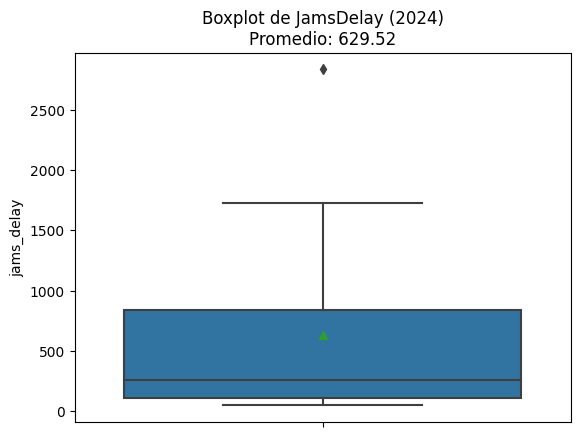

In [49]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged, y="jams_delay", showmeans=True)

mean_value = merged["jams_delay"].mean()
plt.title(f"Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}")
plt.show()


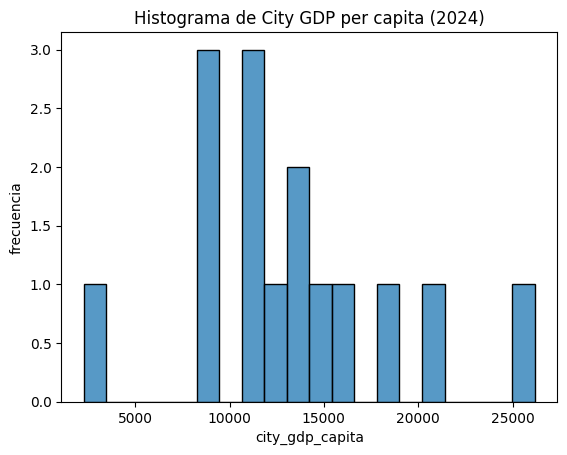

In [50]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=merged, x="city_gdp_capita", bins=20)
plt.title("Histograma de City GDP per capita (2024)")
plt.xlabel("city_gdp_capita")
plt.ylabel("frecuencia")
plt.show()


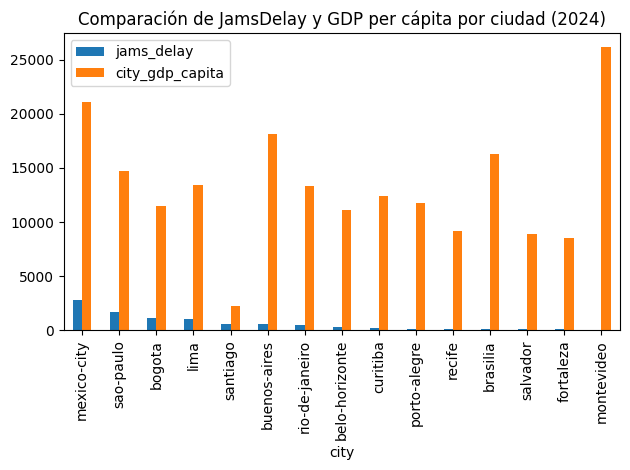

In [51]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
import matplotlib.pyplot as plt

merged.sort_values("jams_delay", ascending=False).plot(
    x="city",
    y=["jams_delay", "city_gdp_capita"],
    kind="bar"
)

plt.xticks(rotation=90)
plt.title("Comparación de JamsDelay y GDP per cápita por ciudad (2024)")
plt.tight_layout()
plt.show()

**Presentation note:** rotating x-axis labels improves readability when multiple city names are displayed in a single chart.


### Analytical Reflection

After reviewing the visualizations, the main question is whether higher economic output tends to move with higher congestion, lower congestion, or no consistent pattern at all.

The answer should be based on the distribution of observations, not on a single outlier.


### Initial Interpretation of the Visual Results

The charts do not suggest a clear linear relationship between higher GDP per capita and higher congestion (`jams_delay`).

Some cities with relatively high GDP show medium or low congestion, while other cities with lower GDP display considerably higher congestion. This indicates that mobility outcomes are likely influenced by additional factors such as infrastructure quality, transit availability, urban design, and local policy conditions.

The presence of outliers in congestion metrics also suggests that extreme cases should be interpreted carefully, since they may distort the visual pattern of the broader sample.


## 7. Output Generation and Documentation

The final stage of the workflow consists of exporting the cleaned analytical dataset and documenting the main findings.

This step makes the project easier to review, reuse, and communicate in a portfolio context.


In [53]:


# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


**Export note:** once the file is generated, it can be downloaded from the notebook environment and stored as a reusable project output.


## Deliverables Included in This Workflow

- Jupyter Notebook (`.ipynb`) containing the full cleaning and analysis process
- Final cleaned CSV dataset for downstream use
- Written summary of methodology, findings, and interpretation


## Executive Summary

### Objective
This project evaluated the relationship between urban mobility conditions and economic performance across Latin American cities by integrating traffic data from TomTom with city-level economic indicators from OECD. The main objective was to build a clean, comparable 2024 dataset that could support exploratory analysis and infrastructure-related interpretation.

### Data Coverage
The workflow used traffic observations aggregated to the city-year level and annual economic indicators for the same period. After cleaning and filtering both sources, only matching city-year records were retained in the final analytical table to ensure consistency across variables.

### Methodology
The process included column standardization, datetime conversion, numeric cleaning of economic indicators, year extraction, 2024 filtering, and aggregation of traffic metrics to the city level. Once both datasets were prepared, they were merged on common identifiers and reviewed through descriptive visualizations to examine distributions, outliers, and possible relationships between congestion and productivity-related indicators.

### Initial Findings
The exploratory results do not show a strong linear relationship between congestion and GDP per capita. Instead, the data suggests a more complex pattern in which highly congested cities may also differ in infrastructure quality, transport alternatives, urban form, and labor-market conditions. Outliers are present in both mobility and economic indicators, which means that rankings and visual comparisons should be interpreted with caution.

### Recommendation
A useful next step would be to create a prioritization framework for infrastructure investment by identifying cities that combine sustained congestion pressure with relatively weaker economic outcomes. This could be strengthened with correlation analysis, regional segmentation, and a composite scoring model based on standardized mobility and economic metrics.
